EDA

Basic data understanding

Shape of the dataset (Rows, Columns): (19520, 271)

First 5 rows of the data:
    ImageName  CellID  Label TrainOrTest    feat_0    feat_1    feat_2  \
0  Image1.jpg       0      0       Train  0.000000  0.000000  0.000000   
1  Image1.jpg       1      0       Train  0.000000  0.002000  0.000800   
2  Image1.jpg       2      3       Train  0.000000  0.037867  0.014667   
3  Image1.jpg       3      3       Train  0.000000  0.057733  0.006800   
4  Image1.jpg       4      3       Train  0.000133  0.067467  0.005733   

     feat_3    feat_4    feat_5  ...    feat_257   feat_258  feat_259  \
0  0.000000  0.000000  0.000000  ...  103.099467   3.470404      91.0   
1  0.000400  0.000000  0.000000  ...  106.136800   6.938488      93.0   
2  0.002000  0.001333  0.000933  ...  114.730133  28.044916      74.0   
3  0.001200  0.001600  0.000133  ...  114.726133  26.762609      74.0   
4  0.000933  0.000800  0.000933  ...  111.367867  29.241327      27.0   

   feat_260  feat_261   feat_262    fe

C:\Users\Student\AppData\Local\Temp\ipykernel_71368\298838476.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Label', data=df, palette='viridis')


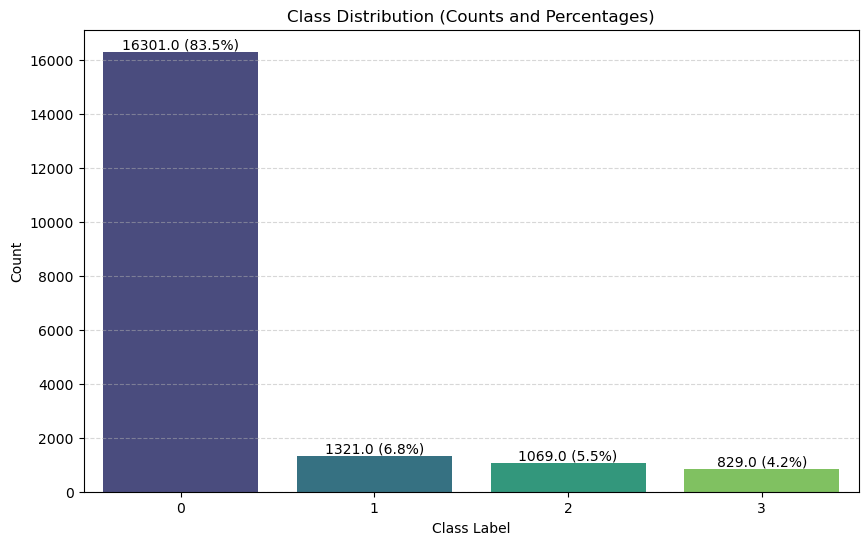

C:\Users\Student\AppData\Local\Temp\ipykernel_71368\298838476.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.countplot(x='TrainOrTest', data=df, palette='pastel')


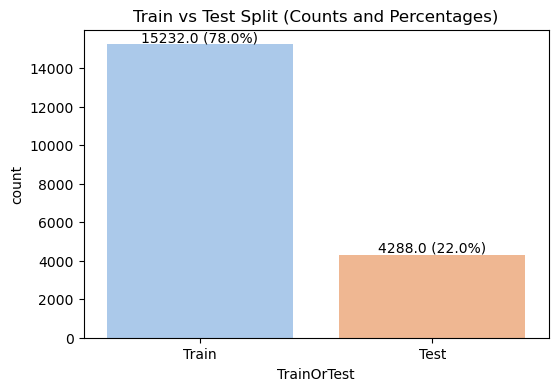

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
file_path = 'extracted_features.csv'
df = pd.read_csv(file_path)

# 2. Display Shape
print("Shape of the dataset (Rows, Columns):", df.shape)

# 3. Display first 5 rows
print("\nFirst 5 rows of the data:")
print(df.head())

# -------------------------------
# Function to annotate bars
# -------------------------------
def annotate_bars(ax, total_count):
    for p in ax.patches:
        height = p.get_height()
        percentage = (height / total_count) * 100
        ax.annotate(
            f'{height} ({percentage:.1f}%)',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=10
        )

# -------------------------------
# 4. Visualization: Class Distribution
# -------------------------------
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='Label', data=df, palette='viridis')

total = len(df)
annotate_bars(ax, total)

plt.title('Class Distribution (Counts and Percentages)')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.savefig('label_distribution.png', bbox_inches='tight')
plt.show()

# -------------------------------
# Optional: Train vs Test Split
# -------------------------------
if 'TrainOrTest' in df.columns:
    plt.figure(figsize=(6, 4))
    ax2 = sns.countplot(x='TrainOrTest', data=df, palette='pastel')

    total_split = len(df)
    annotate_bars(ax2, total_split)

    plt.title('Train vs Test Split (Counts and Percentages)')
    plt.savefig('train_test_split.png', bbox_inches='tight')
    plt.show()


Top 10 feature visualization

C:\Users\Student\AppData\Local\Temp\ipykernel_423704\3101025923.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_vals, y=top_10_labels, palette='magma')


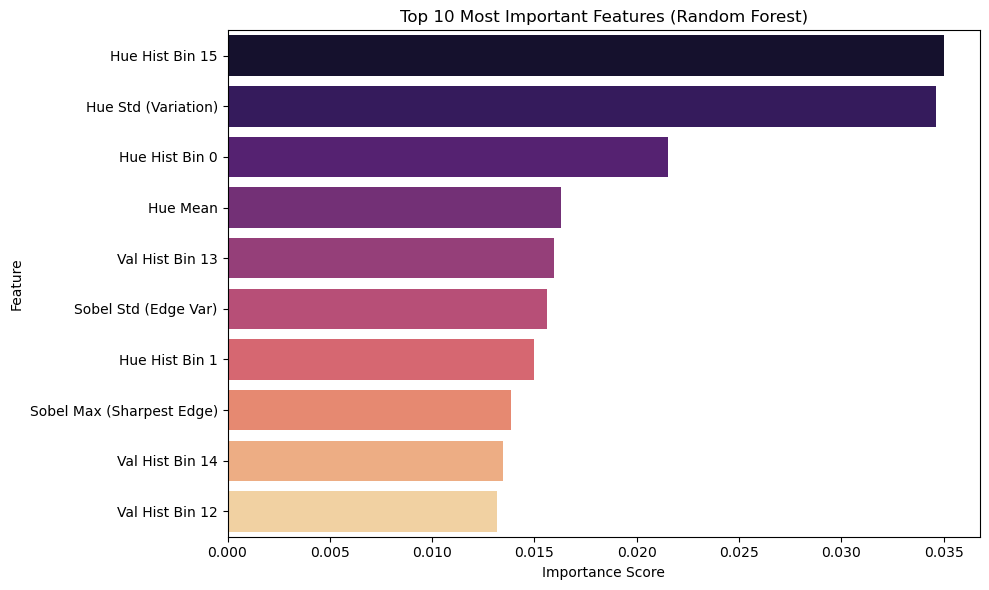

Rank | Feature ID | Description | Importance
--------------------------------------------------
   1 | feat_15    | Hue Hist Bin 15      | 0.0350
   2 | feat_49    | Hue Std (Variation)  | 0.0347
   3 | feat_0     | Hue Hist Bin 0       | 0.0215
   4 | feat_48    | Hue Mean             | 0.0163
   5 | feat_45    | Val Hist Bin 13      | 0.0160
   6 | feat_55    | Sobel Std (Edge Var) | 0.0156
   7 | feat_1     | Hue Hist Bin 1       | 0.0150
   8 | feat_56    | Sobel Max (Sharpest Edge) | 0.0138
   9 | feat_46    | Val Hist Bin 14      | 0.0134
  10 | feat_44    | Val Hist Bin 12      | 0.0132


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# 1. Load and Prepare Data
df = pd.read_csv('extracted_features_Split.csv')
feature_cols = [c for c in df.columns if c.startswith('feat_')]
X = df[feature_cols].fillna(0)  # Handle NaNs
y = df['Label']

# 2. Train Random Forest to measure importance
# n_estimators=100 is standard for a robust estimate
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

# 3. Extract and Sort Feature Importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]  # Sort descending

# Get Top 10
top_10_indices = indices[:10]
top_10_vals = importances[top_10_indices]
top_10_names = [feature_cols[i] for i in top_10_indices]

# 4. Feature Name Mapping Function (Based on your provided class structure)
def get_feature_description(feat_name):
    idx = int(feat_name.split('_')[1])
    
    # Color (0-53)
    if 0 <= idx < 16: return f"Hue Hist Bin {idx}"
    if 16 <= idx < 32: return f"Sat Hist Bin {idx-16}"
    if 32 <= idx < 48: return f"Val Hist Bin {idx-32}"
    if idx == 48: return "Hue Mean"
    if idx == 49: return "Hue Std (Variation)"
    if idx == 50: return "Sat Mean"
    if idx == 51: return "Sat Std"
    if idx == 52: return "Val Mean"
    if idx == 53: return "Val Std"
    
    # Edge (54-66)
    if idx == 54: return "Sobel Mean (Edge Strength)"
    if idx == 55: return "Sobel Std (Edge Var)"
    if idx == 56: return "Sobel Max (Sharpest Edge)"
    if idx == 57: return "Sobel 75%"
    if idx == 58: return "Canny Edge Ratio"
    if 59 <= idx < 67: return f"Edge Angle Bin {idx-59}"
    
    # Texture (67-243)
    if 67 <= idx < 244: return f"LBP Texture {idx}"
    
    # Shape (244-256)
    if 244 <= idx < 251: return f"Hu Moment {idx-244}"
    if idx == 251: return "Num Contours"
    if idx == 252: return "Contour Area Mean"
    if idx == 253: return "Contour Area Std"
    if idx == 254: return "Largest Contour Area"
    if idx == 255: return "Largest Contour Perim"
    if idx == 256: return "Largest Contour Circ"
    
    # Statistical (257-266)
    if idx == 257: return "Pixel Intensity Mean"
    if idx == 262: return "Pixel Skewness"
    if idx == 263: return "Pixel Kurtosis"
    
    return feat_name

# Map names
top_10_labels = [get_feature_description(n) for n in top_10_names]

# 5. Visualize
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_vals, y=top_10_labels, palette='magma')
plt.title('Top 10 Most Important Features (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Print text report
print("Rank | Feature ID | Description | Importance")
print("-" * 50)
for i, (name, desc, val) in enumerate(zip(top_10_names, top_10_labels, top_10_vals)):
    print(f"{i+1:4d} | {name:10s} | {desc:20s} | {val:.4f}")

Basic data understanding

Loaded dataset with 19520 rows and 267 features.
Missing values before cleaning: 964


C:\Users\Student\AppData\Local\Temp\ipykernel_423704\989170226.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Label', data=df, palette='viridis')


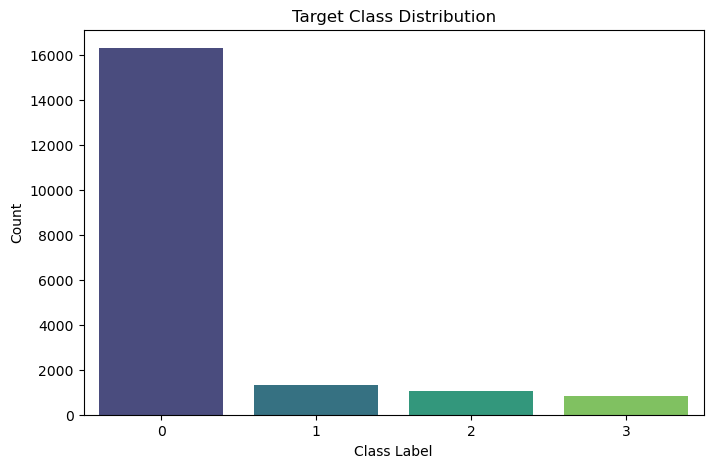

C:\Users\Student\AppData\Local\Temp\ipykernel_423704\989170226.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label', y=col, data=df, showfliers=False, palette='Set2')
C:\Users\Student\AppData\Local\Temp\ipykernel_423704\989170226.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label', y=col, data=df, showfliers=False, palette='Set2')
C:\Users\Student\AppData\Local\Temp\ipykernel_423704\989170226.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label', y=col, data=df, showfliers=False, palette='Set2')
C:\Users\Student

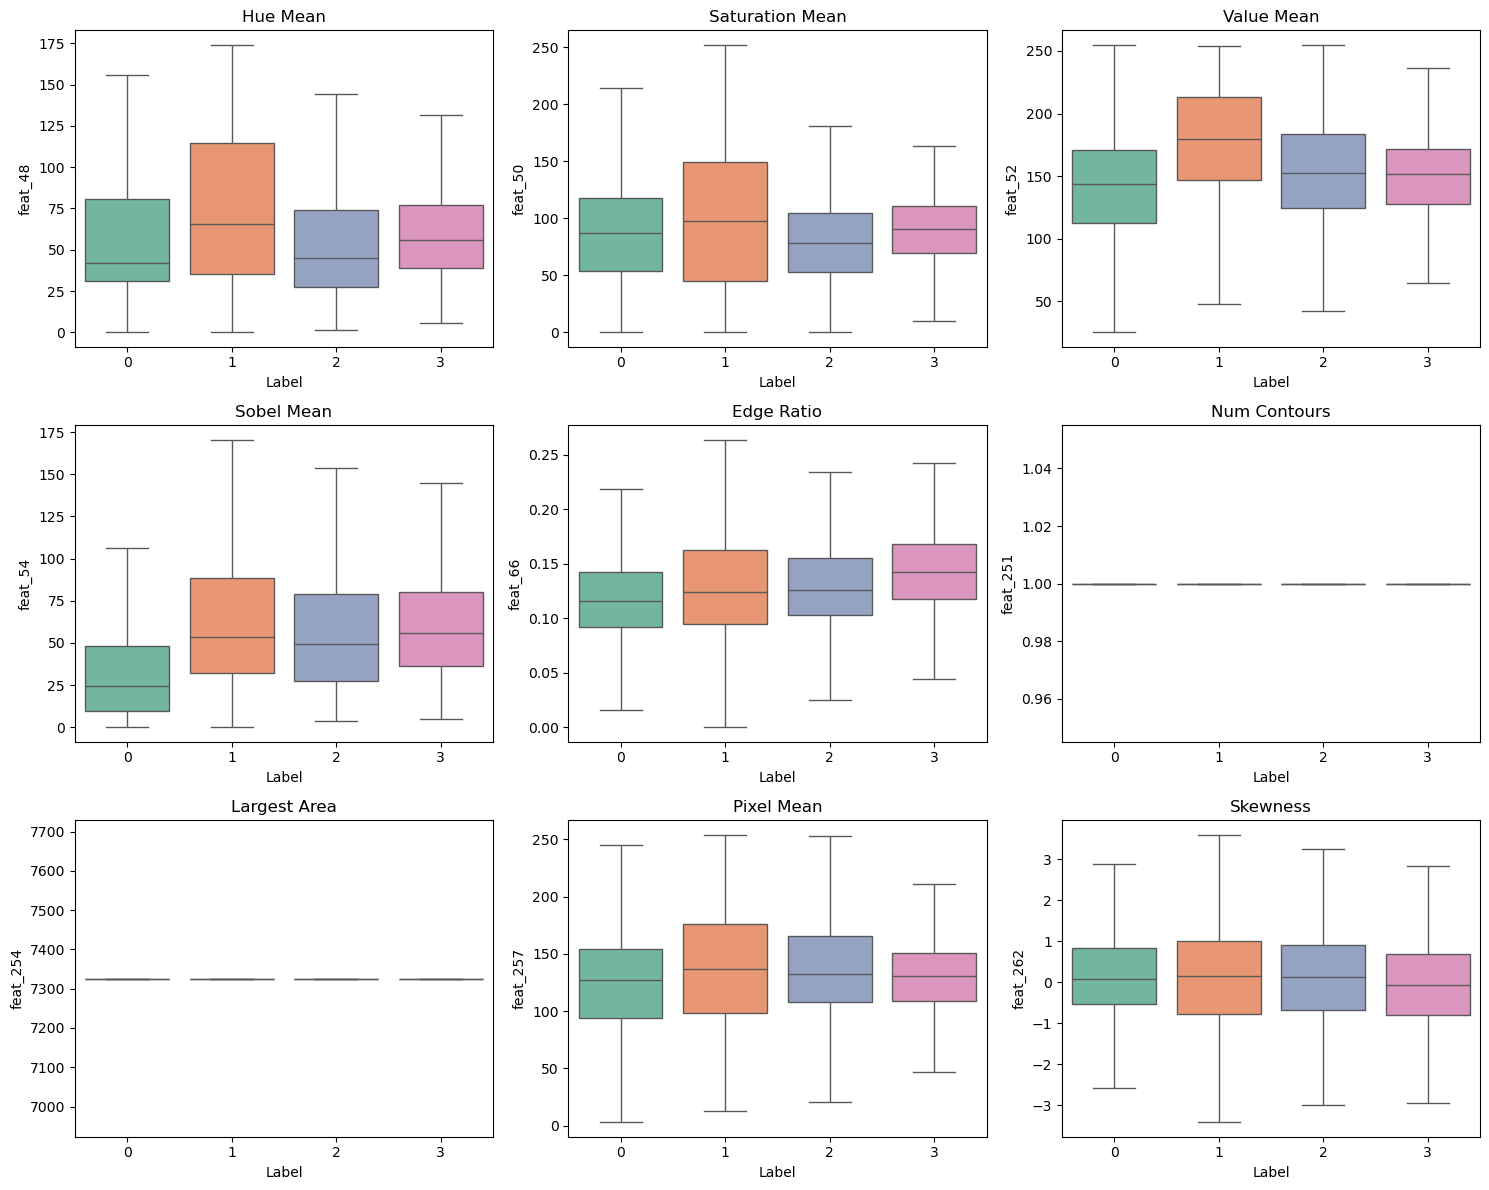

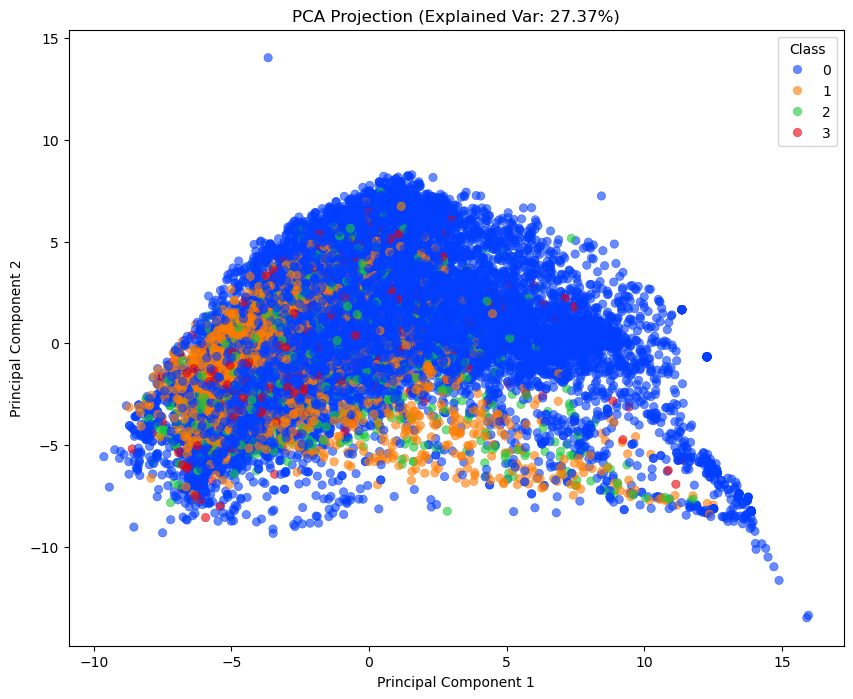

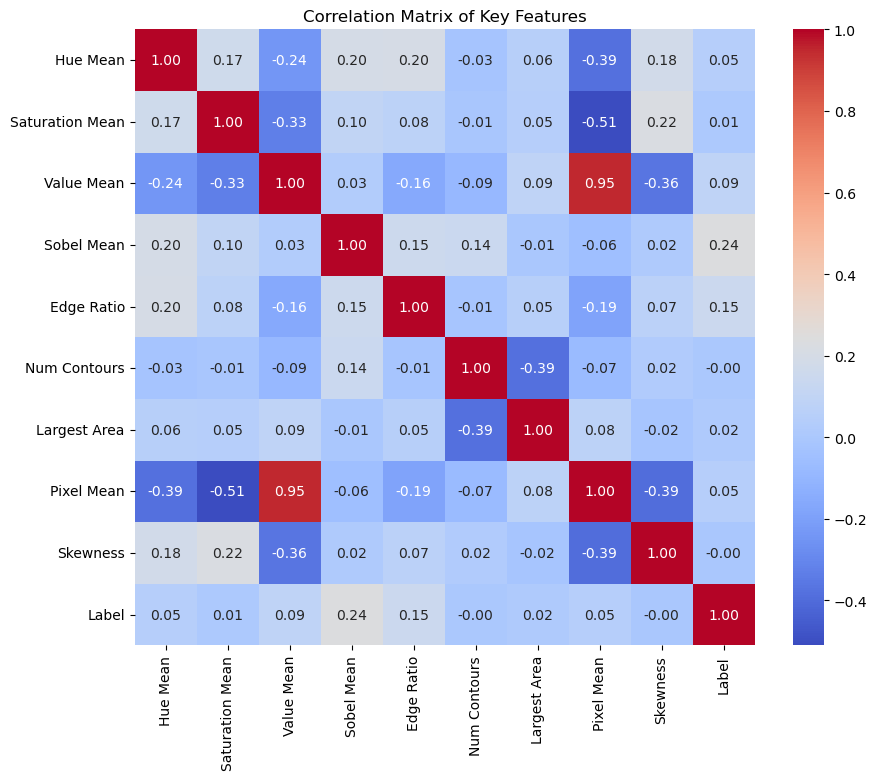

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Load Data
# ---------------------------------------------------------
df = pd.read_csv('extracted_features_Split.csv')

# Identify feature columns (feat_0 to feat_266)
feature_cols = [c for c in df.columns if c.startswith('feat_')]
print(f"Loaded dataset with {df.shape[0]} rows and {len(feature_cols)} features.")

# 2. Data Cleaning
# ---------------------------------------------------------
# Check for missing values (likely in Skew/Kurtosis if variance is 0)
print("Missing values before cleaning:", df[feature_cols].isnull().sum().sum())

# Fill NaNs with 0 (safe for statistical features where std dev = 0)
df[feature_cols] = df[feature_cols].fillna(0)

# 3. Feature Mapping (Based on your extraction code)
# ---------------------------------------------------------
# Color: 54 features (0-53)
# Edge: 13 features (54-66)
# Texture: 177 features (67-243)
# Shape: 13 features (244-256) (Adjusted to match file count)
# Stat: 10 features (257-266)

# Key Representative Features for Visualization
key_features = {
    'Hue Mean': 'feat_48',          # Color
    'Saturation Mean': 'feat_50',   # Color
    'Value Mean': 'feat_52',        # Color
    'Sobel Mean': 'feat_54',        # Edge
    'Edge Ratio': 'feat_66',        # Edge
    'Num Contours': 'feat_251',     # Shape
    'Largest Area': 'feat_254',     # Shape
    'Pixel Mean': 'feat_257',       # Stat
    'Skewness': 'feat_262'          # Stat
}

# 4. Univariate Analysis: Class Distribution
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.countplot(x='Label', data=df, palette='viridis')
plt.title('Target Class Distribution')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.show()

# 5. Bivariate Analysis: Boxplots
# ---------------------------------------------------------
# Boxplots help us see if a feature helps distinguish between classes
plt.figure(figsize=(15, 12))
for i, (name, col) in enumerate(key_features.items()):
    plt.subplot(3, 3, i + 1)
    # limit outliers for cleaner view
    sns.boxplot(x='Label', y=col, data=df, showfliers=False, palette='Set2')
    plt.title(name)
plt.tight_layout()
plt.show()

# 6. Multivariate Analysis: PCA (Dimensionality Reduction)
# ---------------------------------------------------------
# Standardize features first (important for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_cols])

# Compute PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create dataframe for plotting
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Label'] = df['Label']

# Plot PCA
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='Label', 
    data=pca_df, 
    palette='bright', 
    alpha=0.6,
    edgecolor=None
)
plt.title(f'PCA Projection (Explained Var: {np.sum(pca.explained_variance_ratio_):.2%})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Class')
plt.show()

# 7. Correlation Analysis
# ---------------------------------------------------------
# We use the subset of key features to avoid a massive 267x267 heatmap
key_feat_df = df[list(key_features.values())].copy()
key_feat_df.columns = list(key_features.keys())
key_feat_df['Label'] = df['Label']

plt.figure(figsize=(10, 8))
sns.heatmap(key_feat_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Key Features')
plt.show()

Clustering with k means and tsne

--- 1. Loading Data: extracted_features_Split.csv ---
Total Data: 19520
Training Data Selected: 15616
Filling missing values with 0...

--- 2. Running K-Means (k=4) ---
Running t-SNE (This might take a minute)...
Subsampling 10,000 points for visualization speed...

--- 3. Generating Visualization ---


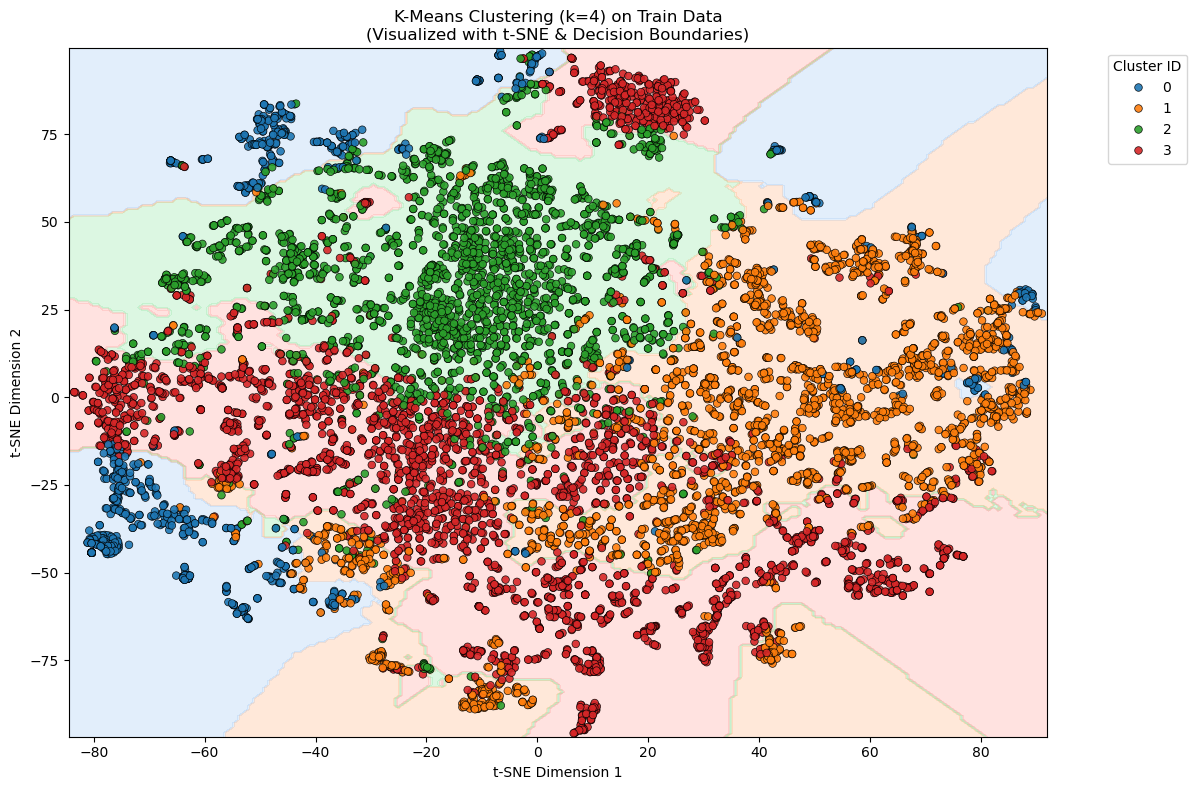

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import ListedColormap

# --- CONFIGURATION ---
INPUT_FILE = "extracted_features_Split.csv"
FIXED_K = 4  # Number of clusters

def load_train_data():
    print(f"--- 1. Loading Data: {INPUT_FILE} ---")
    if not os.path.exists(INPUT_FILE):
        print(f"Error: {INPUT_FILE} not found. Please run the split script first.")
        return None

    df = pd.read_csv(INPUT_FILE)
    
    # Filter for TRAIN data only
    train_df = df[df['TrainOrTest'] == 'Train'].copy()
    print(f"Total Data: {len(df)}")
    print(f"Training Data Selected: {len(train_df)}")
    
    # Drop Metadata and Labels to get just features
    # (We ignore 'y'/'Label' for clustering since this is unsupervised)
    cols_to_drop = ['ImageName', 'CellID', 'y', 'TrainOrTest', 'Label_Name', 'Label']
    X = train_df.drop(columns=[c for c in cols_to_drop if c in train_df.columns])
    
    # --- UPDATE: Fill Missing Values ---
    print("Filling missing values with 0...")
    X = X.fillna(0)
    
    # Scale Data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    return X_scaled

def run_kmeans_tsne(X_scaled):
    print(f"\n--- 2. Running K-Means (k={FIXED_K}) ---")
    
    # 1. K-Means
    kmeans = KMeans(n_clusters=FIXED_K, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    # 2. t-SNE (Dimensionality Reduction)
    print("Running t-SNE (This might take a minute)...")
    # Subsample if dataset is too large (>10k) for speed, otherwise use full
    if len(X_scaled) > 10000:
        print("Subsampling 10,000 points for visualization speed...")
        idx = np.random.choice(len(X_scaled), 10000, replace=False)
        X_vis = X_scaled[idx]
        y_vis = cluster_labels[idx]
    else:
        X_vis = X_scaled
        y_vis = cluster_labels

    tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
    X_tsne = tsne.fit_transform(X_vis)
    
    return X_tsne, y_vis

def plot_clusters_with_boundaries(X_tsne, labels):
    print("\n--- 3. Generating Visualization ---")
    
    plt.figure(figsize=(12, 8))
    
    # 1. Create Meshgrid for Background Boundaries
    resolution = 200
    x_min, x_max = X_tsne[:, 0].min() - 1, X_tsne[:, 0].max() + 1
    y_min, y_max = X_tsne[:, 1].min() - 1, X_tsne[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, resolution),
                         np.linspace(y_min, y_max, resolution))

    # 2. Train a KNN to "paint" the background based on nearest cluster
    knn = KNeighborsClassifier(n_neighbors=30)
    knn.fit(X_tsne, labels)
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # 3. Define Colors
    # Using a distinct palette
    cmap_background = ListedColormap(sns.color_palette("pastel", FIXED_K))
    cmap_points = sns.color_palette("tab10", FIXED_K)

    # 4. Plot Background (Contour)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_background)

    # 5. Plot Data Points
    sns.scatterplot(
        x=X_tsne[:, 0], 
        y=X_tsne[:, 1], 
        hue=labels, 
        palette=cmap_points, 
        s=30, 
        edgecolor='k', 
        linewidth=0.5,
        alpha=0.9
    )
    
    plt.title(f'K-Means Clustering (k={FIXED_K}) on Train Data\n(Visualized with t-SNE & Decision Boundaries)')
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.legend(title='Cluster ID', loc='upper right', bbox_to_anchor=(1.15, 1))
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    X_scaled = load_train_data()
    if X_scaled is not None:
        X_tsne, labels = run_kmeans_tsne(X_scaled)
        plot_clusters_with_boundaries(X_tsne, labels)

Features visualization

--- Processing Dataset_final\Image291.jpg ---


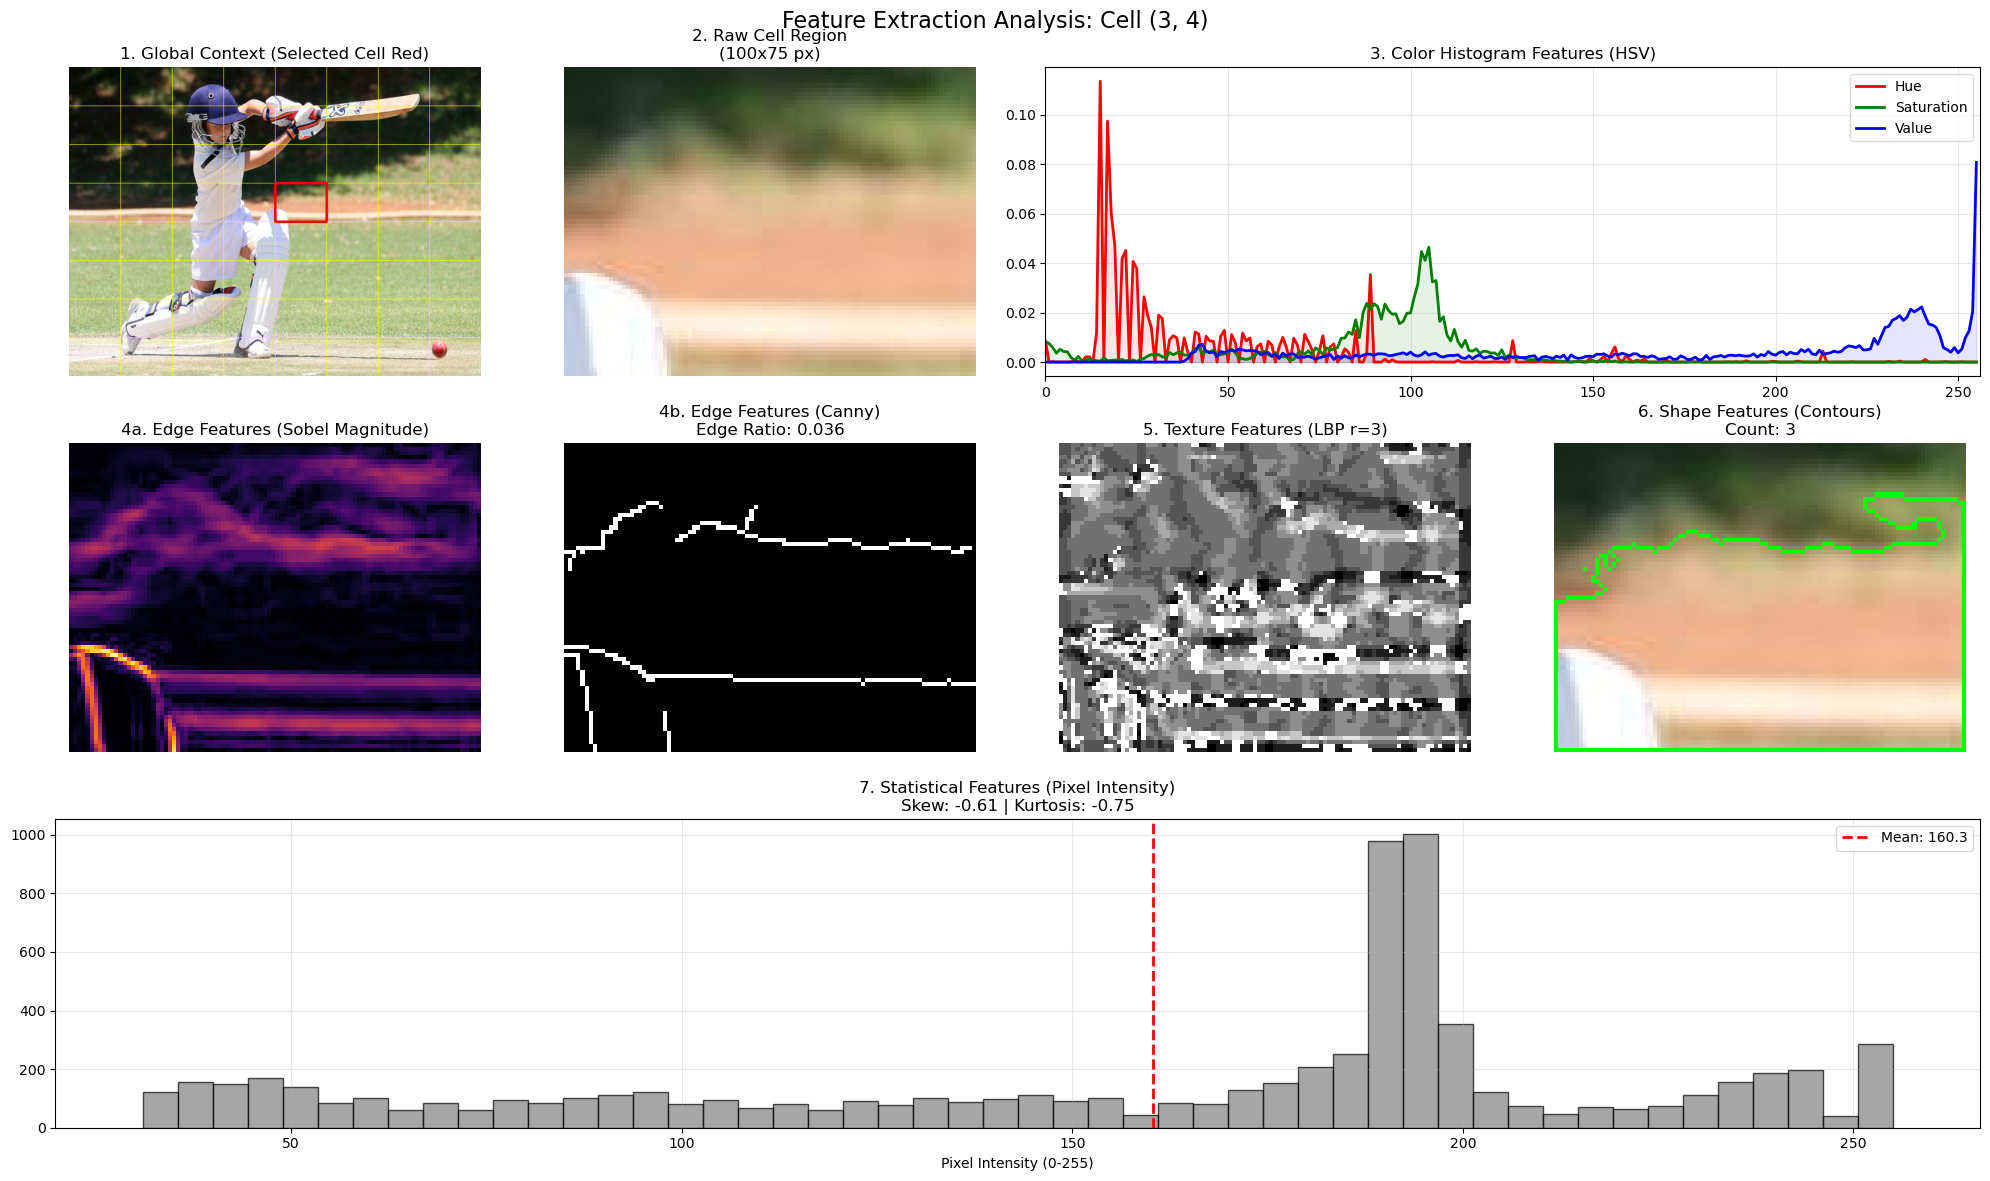

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from skimage.feature import local_binary_pattern
from scipy import stats

# --- CONFIGURATION ---
IMAGE_NAME = "Image291.jpg"       # The specific image to process
IMAGE_DIR = "Dataset_final"       # Folder where the image is located
IMG_WIDTH, IMG_HEIGHT = 800, 600  # Standard dimensions
GRID_ROWS, GRID_COLS = 8, 8       # Grid size

# Select a specific cell to visualize (0-indexed)
# Row 3, Col 4 is usually near the pitch/action area
TARGET_ROW = 3 
TARGET_COL = 4

def get_image_path(image_dir, image_name):
    """Handles path resolution and extension checking."""
    full_path = os.path.join(image_dir, image_name)
    if not os.path.exists(full_path):
        # Try finding with other extensions
        base_name = os.path.splitext(full_path)[0]
        for ext in ['.jpg', '.png', '.jpeg']:
            if os.path.exists(base_name + ext):
                return base_name + ext
        return None
    return full_path

def visualize_grid_features():
    path = get_image_path(IMAGE_DIR, IMAGE_NAME)
    if not path:
        print(f"Error: Image {IMAGE_NAME} not found in {IMAGE_DIR}")
        return

    print(f"--- Processing {path} ---")
    img = cv2.imread(path)
    if img is None:
        print("Error: Could not read image.")
        return

    # 1. Preprocessing (Resize)
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    
    # 2. Extract Grid Cell
    cell_h = IMG_HEIGHT // GRID_ROWS
    cell_w = IMG_WIDTH // GRID_COLS
    y_start = TARGET_ROW * cell_h
    y_end = (TARGET_ROW + 1) * cell_h
    x_start = TARGET_COL * cell_w
    x_end = (TARGET_COL + 1) * cell_w
    
    cell = img[y_start:y_end, x_start:x_end]
    gray_cell = cv2.cvtColor(cell, cv2.COLOR_BGR2GRAY)

    # --- DASHBOARD SETUP ---
    fig = plt.figure(figsize=(20, 12))
    fig.suptitle(f"Feature Extraction Analysis: Cell ({TARGET_ROW}, {TARGET_COL})", fontsize=16)
    
    # Layout: 3 Rows, 4 Columns
    gs = fig.add_gridspec(3, 4)

    # --- A. Context (Original Image + Grid) ---
    ax_orig = fig.add_subplot(gs[0, 0])
    img_grid = img.copy()
    # Draw Grid
    for i in range(1, GRID_COLS):
        cv2.line(img_grid, (i * cell_w, 0), (i * cell_w, IMG_HEIGHT), (0, 255, 255), 1)
    for i in range(1, GRID_ROWS):
        cv2.line(img_grid, (0, i * cell_h), (IMG_WIDTH, i * cell_h), (0, 255, 255), 1)
    # Highlight Selected Cell
    cv2.rectangle(img_grid, (x_start, y_start), (x_end, y_end), (0, 0, 255), 3)
    
    ax_orig.imshow(cv2.cvtColor(img_grid, cv2.COLOR_BGR2RGB))
    ax_orig.set_title("1. Global Context (Selected Cell Red)")
    ax_orig.axis("off")

    # --- B. The Raw Cell ---
    ax_cell = fig.add_subplot(gs[0, 1])
    ax_cell.imshow(cv2.cvtColor(cell, cv2.COLOR_BGR2RGB))
    ax_cell.set_title(f"2. Raw Cell Region\n({cell_w}x{cell_h} px)")
    ax_cell.axis("off")

    # --- METHOD 1: COLOR FEATURES (HSV Histograms) ---
    ax_color = fig.add_subplot(gs[0, 2:])
    hsv = cv2.cvtColor(cell, cv2.COLOR_BGR2HSV)
    colors = ['r', 'g', 'b'] # Using RGB colors for plot lines for visibility
    labels = ['Hue', 'Saturation', 'Value']
    ranges = [180, 256, 256]
    
    for i, color in enumerate(colors):
        hist = cv2.calcHist([hsv], [i], None, [256], [0, ranges[i]])
        # Normalize for visualization
        hist = hist / (hist.sum() + 1e-6)
        ax_color.plot(hist, color=color, label=labels[i], linewidth=2)
        ax_color.fill_between(range(256), hist.flatten(), color=color, alpha=0.1)
    
    ax_color.set_title("3. Color Histogram Features (HSV)")
    ax_color.set_xlim([0, 256])
    ax_color.legend()
    ax_color.grid(True, alpha=0.3)

    # --- METHOD 2: EDGE FEATURES (Sobel & Canny) ---
    # Sobel
    ax_sobel = fig.add_subplot(gs[1, 0])
    sobelx = cv2.Sobel(gray_cell, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray_cell, cv2.CV_64F, 0, 1, ksize=3)
    sobel_mag = np.sqrt(sobelx**2 + sobely**2)
    # Normalize for display
    sobel_disp = cv2.normalize(sobel_mag, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    
    ax_sobel.imshow(sobel_disp, cmap='inferno')
    ax_sobel.set_title("4a. Edge Features (Sobel Magnitude)")
    ax_sobel.axis("off")

    # Canny
    ax_canny = fig.add_subplot(gs[1, 1])
    edges = cv2.Canny(gray_cell, 50, 150)
    ax_canny.imshow(edges, cmap='gray')
    ax_canny.set_title(f"4b. Edge Features (Canny)\nEdge Ratio: {edges.mean()/255:.3f}")
    ax_canny.axis("off")

    # --- METHOD 3: TEXTURE FEATURES (LBP) ---
    ax_lbp = fig.add_subplot(gs[1, 2])
    # Using radius=3 as in your code loop
    lbp = local_binary_pattern(gray_cell, 8, 3, method='uniform')
    ax_lbp.imshow(lbp, cmap='gray')
    ax_lbp.set_title("5. Texture Features (LBP r=3)")
    ax_lbp.axis("off")

    # --- METHOD 4: SHAPE FEATURES (Contours) ---
    ax_shape = fig.add_subplot(gs[1, 3])
    # Binary Threshold (Otsu)
    _, binary = cv2.threshold(gray_cell, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Find Contours
    cnts = cv2.findContours(binary, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    contours = cnts[1] if len(cnts) == 3 else cnts[0]
    
    # Draw on copy
    cell_cnt = cell.copy()
    cv2.drawContours(cell_cnt, contours, -1, (0, 255, 0), 1)
    
    ax_shape.imshow(cv2.cvtColor(cell_cnt, cv2.COLOR_BGR2RGB))
    ax_shape.set_title(f"6. Shape Features (Contours)\nCount: {len(contours)}")
    ax_shape.axis("off")

    # --- METHOD 5: STATISTICAL FEATURES (Distribution) ---
    ax_stat = fig.add_subplot(gs[2, :])
    pixel_vals = gray_cell.flatten()
    
    # Calculate stats for display
    mean_val = np.mean(pixel_vals)
    skew_val = stats.skew(pixel_vals)
    kurt_val = stats.kurtosis(pixel_vals)
    
    ax_stat.hist(pixel_vals, bins=50, color='gray', alpha=0.7, edgecolor='black')
    ax_stat.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
    
    ax_stat.set_title(f"7. Statistical Features (Pixel Intensity)\nSkew: {skew_val:.2f} | Kurtosis: {kurt_val:.2f}")
    ax_stat.set_xlabel("Pixel Intensity (0-255)")
    ax_stat.legend()
    ax_stat.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    visualize_grid_features()

# 